# Definitions

In [1]:
# DEFINIZIONI

import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from numpy import pi, sqrt, linspace, exp, sin, cos, abs, angle, log, max, real
from scipy.special import erf, erfc
from scipy.integrate import cumulative_trapezoid
from math import atan2
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.ticker as ticker

nlev = 2
nqubit = 2

k = 10
chi = 1*k
dchi = .0
chi1 = (1+dchi)*chi
chi2 = (1-dchi)*chi 

def u(t):  # Forma dell'impulso (definisce la scala dei tempi)
    out = sqrt(1/sqrt(pi)*exp(-t**2))
    return float(out)

def gu(t):  # Accoppiamento modulabile source per restituire u(t)
    out = sqrt(2/sqrt(pi)*exp(-t**2)/erfc(t))
    return float(out)

def OpL(t, gm): # Operatore di Lindblad
    return sqrt(gm)*a + gu(t)*ain

def initsim(nq=1, nl=2): # Inizializza la simulazione preparando gli operatori necessari
    global ain, a, ainc, ac, sx, sy, sz, roty, nqubit, nlev
    nqubit = nq
    nlev = nl
    ain = tensor(destroy(nlev), identity(nlev))
    a = tensor(identity(nlev), destroy(nlev))
    ident = tensor(identity(nlev), identity(nlev))
    rot0 = Qobj([[1, -1], [1, 1]]/sqrt(2))
    sx = []
    sy = []
    sz = []
    roty = ident
    for i in range(nqubit):
        ain = tensor(ain, identity(2))
        a = tensor(a, identity(2))
        roty = tensor(roty, rot0)
        sx.append(ident)
        sy.append(ident)
        sz.append(ident)
        for j in range(nqubit):
            sx[i]=tensor(sx[i], sigmax() if i==j else identity(2))
            sy[i]=tensor(sy[i], sigmay() if i==j else identity(2))
            sz[i]=tensor(sz[i], sigmaz() if i==j else identity(2))
    ainc = ain.dag()
    ac = a.dag()

def sim(gm = 10, chi = [], t1=-3, t2=3, nsteps=100): # Simulazione
    t_ = linspace(t1, t2, nsteps)
    psi0 = tensor(basis(nlev,1), basis(nlev,0))
    for i in range(nqubit):
        psi0 = tensor(psi0, (basis(2,0)+basis(2,1))/sqrt(2))
    Hc = 1j/2*sqrt(gm)*(ainc*a-ain*ac)
    Hq = 0
    for i in range(nqubit):
        Hq = Hq -chi[i]/2*ac*a*sz[i]
    H = [Hq,[Hc, gu]]
    L = [lambda t, args: OpL(t, gm)]
    rho_ = mesolve(H, psi0, t_, L).states
    return t_, rho_

def plotrho(rho): # Plot della matrice densità con l'approccio clocklike
    fig, ax = plt.subplots()
    R = .45
    amp = abs(rho.full())
    phase = angle(rho.full())
    N = len(amp)
    bit = int(np.log2(N))
    circ = []
    lin = []
    for i in range(N):
        ax.text(i-.1, -.8, bin(i)[2:].zfill(bit), fontsize=8, color='black', ha='center', va='top', rotation = -90)
        ax.text(-.8, i-.1, bin(i)[2:].zfill(bit), fontsize=8, color='black', ha='right')
        for j in range(N):
            circle0 = plt.Circle((i, j), R, fill=False, edgecolor='blue', linewidth=.2)
            ax.add_patch(circle0)
            square = plt.Rectangle((i-.5, j-.5), 1, 1, fill=False, edgecolor='black', linewidth=.1)
            ax.add_patch(square)
            circle = plt.Circle((i, j), R*sqrt(amp[i,j]), color=plt.cm.hsv((phase[i,j]/(2*pi)+.5)%1), alpha=.5)
            circ.append(ax.add_patch(circle))
            pl, = ax.plot([i, i + R*sqrt(amp[i,j])*np.cos(phase[i,j])], [j, j + R*amp[i,j]*np.sin(phase[i,j])], color='black', linewidth=0.8)
            lin.append(pl)
    ax.set_aspect('equal')
    ax.set_xlim(-0.5, N-0.5)
    ax.set_ylim(-1., N-0.5)
    ax.axis('off')
    return fig, ax, circ, lin

def animaterho(t_,rho_): # Animazione della matrice densità con l'approccio clocklike
    fig, ax, circ, lin = plotrho(rho_[0])
    plt.close()
    N = int(sqrt(len(circ)))
    def update(frame):
        R = .45
        rho = rho_[frame].full()
        amp = sqrt(abs(rho))
        phase = angle(rho)
        for i in range(N):
            for j in range(N):
                circ[i+N*j].set_radius(R*amp[i,j])
                circ[i+N*j].set_color(plt.cm.hsv((phase[i,j]/(2*pi)+.5)%1))
                lin[i+N*j].set_data([i, i + R*amp[i,j]*np.cos(phase[i,j])], [j, j + R*amp[i,j]*np.sin(phase[i,j])])
        ax.set_title(f"t = {t_[frame]:.2f} frame={frame}")
        return circ, lin
    anim = FuncAnimation(fig, update, frames=len(t_), blit=False, repeat=False)
    return anim

def rotation(rho): # Rotazione finale della matrice densità
    rho1 = roty*rho*roty.dag()
    return rho1
    
def prob(rho): # Diagonal elements of a density matrix
    rhored = ptrace(rho, [kq+2 for kq in range(nqubit)])
    return abs(np.diag(rhored.full()))

def phaseq(rho):
    return [angle((ptrace(rho, 2+kq).full())[0,1])%(2*pi) for kq in range(nqubit)]

def plotpop(t_, rho_, gm):
    Pin_ = [expect(ainc*ain,rho) for rho in rho_] 
    Pc_ = [expect(ac*a,rho) for rho in rho_]
    Iin_ = -np.gradient(Pin_,t_)
    Iout_ = [expect(OpL(t,gm).dag()*OpL(t,gm), rho_[kt]) for kt,t in enumerate(t_)]
    Pout_ = cumulative_trapezoid(Iout_, t_, initial=0)
    fig, ax = plt.subplots()
    ax.plot(t_, Pin_, label='Pop in')
    ax.plot(t_, Pc_, label='Pop cavity')
    ax.plot(t_, Pout_, label='Pop out')
    ax.plot(t_, Iin_, label='Flux in')
    ax.plot(t_, Iout_, label='Flux out')
    ax.set_xlabel('Time')
    ax.set_ylabel('Population / Flux')
    plt.legend()
    return Iin_

def plotphase(t_, rho_):
    fig, ax = plt.subplots()
    for kq in range(nqubit):
        Pphase_ = [phaseq(rho) for rho in rho_]
        ax.plot(t_, Pphase_, label=f'Phase qubit {kq+1}')
    ax.plot(t_, np.zeros_like(t_), color='gray', linestyle='--', linewidth=0.8)
    ax.plot(t_, np.zeros_like(t_)+pi/2, color='gray', linestyle='--', linewidth=0.8)
    ax.plot(t_, np.zeros_like(t_)+pi, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Time')
    ax.set_ylabel(r'Phase $\delta\theta$ (rad)')
    plt.legend()

## Test

[9.99684170e-01 3.15830433e-04]


<Figure size 432x288 with 0 Axes>

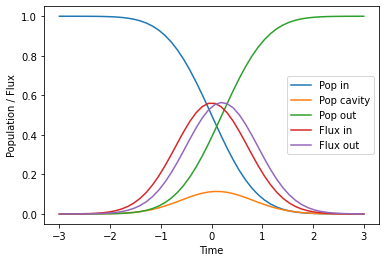

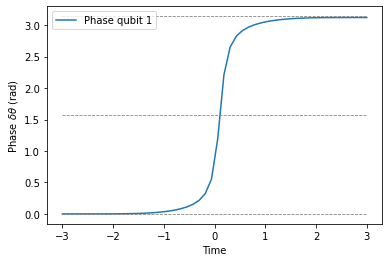

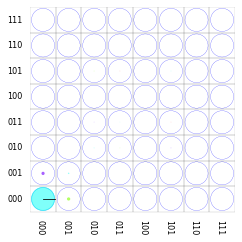

In [3]:
# TEST 1 QUBIT

initsim(nq=1,nl=2)
t_,rho_ = sim(gm=10, chi=[10,10,10], nsteps=50)

rho1 = rotation(rho_[-1])
print(prob(rho1))

plt.figure(1)
plotpop(t_,rho_,10)
plotphase(t_, rho_)
plotrho(rho1)

# anim = animaterho(t_, rho_)
anim = animaterho(t_, [ptrace(rho,[1,2]) for rho in rho_])
#HTML(anim.to_html5_video())
HTML(anim.to_jshtml())

[0.97626203 0.00248782 0.00248782 0.01876232]


<Figure size 432x288 with 0 Axes>

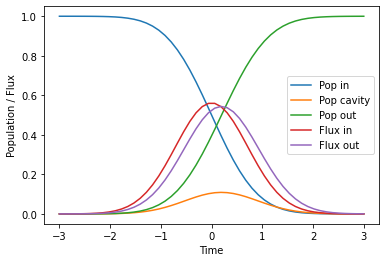

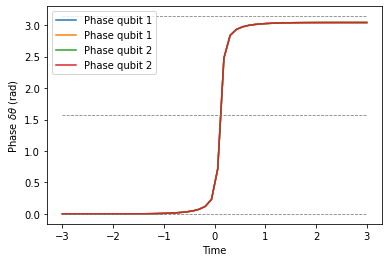

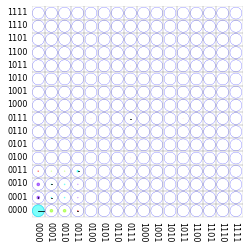

In [4]:
# TEST 2 QUBIT

initsim(nq=2,nl=2)
t_,rho_ = sim(gm=10, chi=[100,100,100], nsteps=50)

rho1 = rotation(rho_[-1])
print(prob(rho1))

plt.figure(1)
plotpop(t_,rho_,10)
plotphase(t_, rho_)
plotrho(rho1)

# anim = animaterho(t_, rho_)
anim = animaterho(t_, [ptrace(rho,[1,2,3]) for rho in rho_])
# HTML(anim.to_html5_video())
HTML(anim.to_jshtml())

[0.3460997  0.01743798 0.01743798 0.1136209  0.01743798 0.1136209
 0.1136209  0.26072365]


<Figure size 432x288 with 0 Axes>

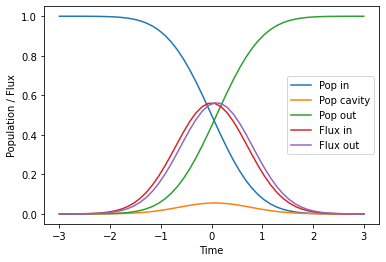

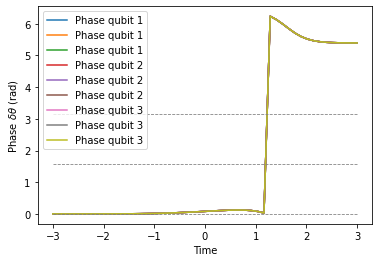

In [5]:
# TEST 3 QUBIT

initsim(nq=3,nl=2)
t_,rho_ = sim(gm=10, chi=[15,15,15], nsteps=50)

rho1 = rotation(rho_[-1])
print(prob(rho1))

plt.figure(1)
plotpop(t_,rho_,10)
plotphase(t_, rho_)
# plotrho(rho1)

# anim = animaterho(t_, rho_)
anim = animaterho(t_, [ptrace(rho,[1,2,3,4]) for rho in rho_])
# HTML(anim.to_html5_video())
HTML(anim.to_jshtml())

## Sweep on $\chi/\gamma$

Text(0, 0.5, 'Phase $\\delta\\theta$ (rad)')

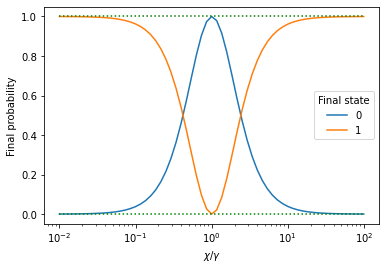

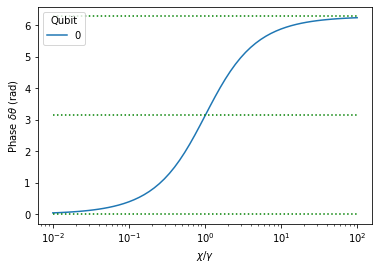

In [6]:
# SWEEP CHI/GAMMA, 1 QUBIT
gm = 10
chi_ = np.logspace(-2,2,61)*gm
P_ = []
ph_ = []
initsim(nq=1)
for chi in chi_:
    t_,rho_ = sim(gm=gm, chi=[chi], nsteps=10)
    rho1 = rotation(rho_[-1])
    P_.append(prob(rho1))
    ph_.append(phaseq(rho_[-1]))
fig, ax = plt.subplots()
lines = plt.plot(chi_/gm, P_)
ax.legend(title='Final state', handles=lines, labels=[bin(k)[2:].zfill(nqubit) for k in range(2**(nqubit))])
plt.plot(chi_/gm, 0+np.zeros_like(chi_), 'g:')
plt.plot(chi_/gm, 1+np.zeros_like(chi_), 'g:')
ax.set_xscale('log')
ax.set_xlabel(r'$\chi/\gamma$')
ax.set_ylabel('Final probability')
plt.figure(2)
lines = plt.plot(chi_/gm, ph_)
plt.plot(chi_/gm, 0+np.zeros_like(chi_), 'g:')
plt.plot(chi_/gm, pi+np.zeros_like(chi_), 'g:')
plt.plot(chi_/gm, 2*pi+np.zeros_like(chi_), 'g:')
plt.legend(title='Qubit', handles=lines, labels=[bin(k)[2:].zfill(nqubit) for k in range(nqubit)])
plt.xscale('log')
plt.xlabel(r'$\chi/\gamma$')
plt.ylabel(r'Phase $\delta\theta$ (rad)')

Text(0, 0.5, 'Phase (rad)')

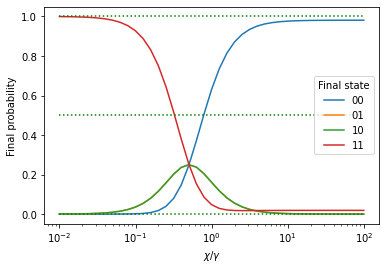

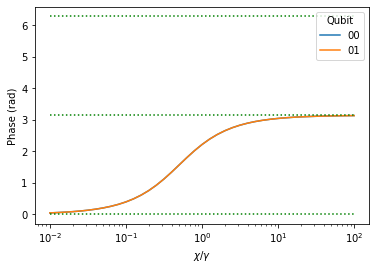

In [7]:
# SWEEP CHI/GAMMA, 2 QUBIT
gm = 10
chi_ = np.logspace(-2,2,41)*gm
P_ = []
ph_ = []
initsim(nq=2)
for chi in chi_:
    t_,rho_ = sim(gm=gm, chi=[chi, chi], nsteps=50)
    rho1 = rotation(rho_[-1])
    P_.append(prob(rho1))
    # ph_.append(phaseq(rho_[-1]))
    ph_.append([angle((ptrace(rho_[-1],3).full())[0,1]) for kq in range(nqubit)])
fig, ax = plt.subplots()
lines = plt.plot(chi_/gm, P_)
plt.plot(chi_/gm, 0+np.zeros_like(chi_), 'g:')
plt.plot(chi_/gm, .5+np.zeros_like(chi_), 'g:')
plt.plot(chi_/gm, 1+np.zeros_like(chi_), 'g:')
ax.legend(title='Final state', handles=lines, labels=[bin(k)[2:].zfill(nqubit) for k in range(2**(nqubit))])
ax.set_xscale('log')
ax.set_xlabel(r'$\chi/\gamma$')
ax.set_ylabel('Final probability')
plt.figure(2)
lines = plt.plot(chi_/gm, ph_)
plt.plot(chi_/gm, 0+np.zeros_like(chi_), 'g:')
plt.plot(chi_/gm, pi+np.zeros_like(chi_), 'g:')
plt.plot(chi_/gm, 2*pi+np.zeros_like(chi_), 'g:')
plt.legend(title='Qubit', handles=lines, labels=[bin(k)[2:].zfill(nqubit) for k in range(nqubit)])
plt.xscale('log')
plt.xlabel(r'$\chi/\gamma$')
plt.ylabel('Phase (rad)')

Text(0, 0.5, 'Phase (rad)')

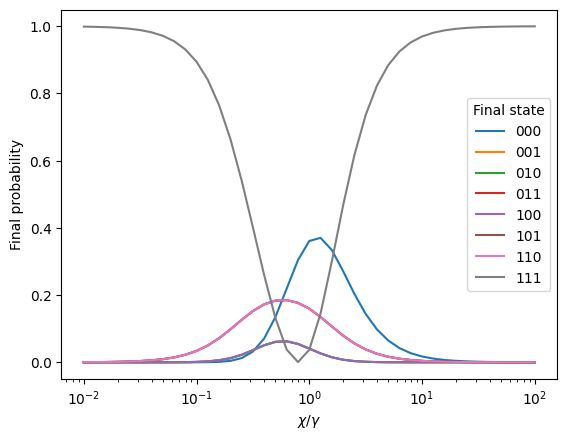

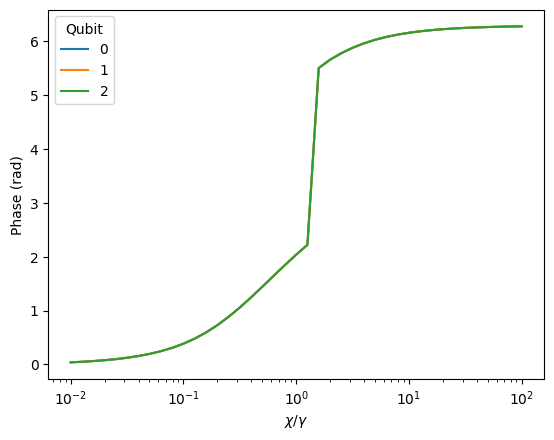

In [8]:
# SWEEP CHI/GAMMA, 3 QUBIT
gm = 10
chi_ = np.logspace(-2,2,41)*gm
P_ = []
ph_ = []
initsim(nq=3)
for chi in chi_:
    t_,rho_ = sim(gm=gm, chi=[chi, chi, chi], nsteps=50)
    rho1 = rotation(rho_[-1])
    P_.append(prob(rho1))
    ph_.append(phaseq(rho_[-1]))
fig, ax = plt.subplots()
lines = plt.plot(chi_/gm, P_)
ax.legend(title='Final state', handles=lines, labels=[bin(k)[2:].zfill(nqubit) for k in range(2**(nqubit))])
ax.set_xscale('log')
ax.set_xlabel(r'$\chi/\gamma$')
ax.set_ylabel('Final probability')
plt.figure(2)
lines = plt.plot(chi_/gm, ph_)
plt.legend(title='Qubit', handles=lines, labels=[k for k in range(nqubit)])
plt.xscale('log')
plt.xlabel(r'$\chi/\gamma$')
plt.ylabel('Phase (rad)')

In [215]:
prob(rho1)

array([1.33395536e-10, 1.50987309e-07, 1.50987309e-07, 3.84667748e-04,
       1.50987309e-07, 3.84667748e-04, 3.84667748e-04, 9.98711152e-01,
       1.03637286e-13, 4.98733275e-11, 4.98733275e-11, 4.29241874e-08,
       4.98733275e-11, 4.29241874e-08, 4.29241874e-08, 1.23232482e-04,
       3.36905292e-21, 3.33161900e-21, 3.36905292e-21, 2.35833704e-21,
       3.36905292e-21, 2.35833704e-21, 2.32090312e-21, 1.10297618e-05,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

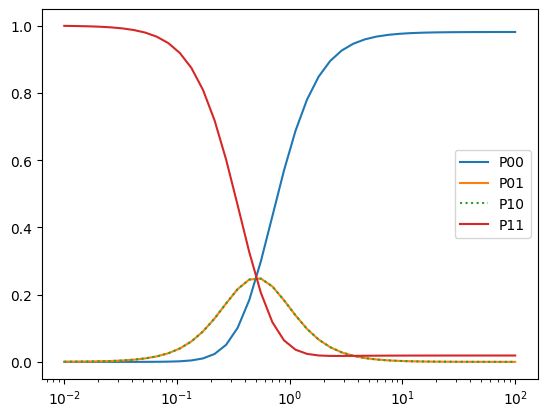

In [44]:
plt.plot(chi_/gm, np.array(P_)[:,0], label='P00')
plt.plot(chi_/gm, np.array(P_)[:,1], label='P01')
plt.plot(chi_/gm, np.array(P_)[:,2],':', label='P10')
plt.plot(chi_/gm, np.array(P_)[:,3], label='P11')
plt.xscale('log')
plt.legend()

# Cavity, no qubit

0.8003032186935598


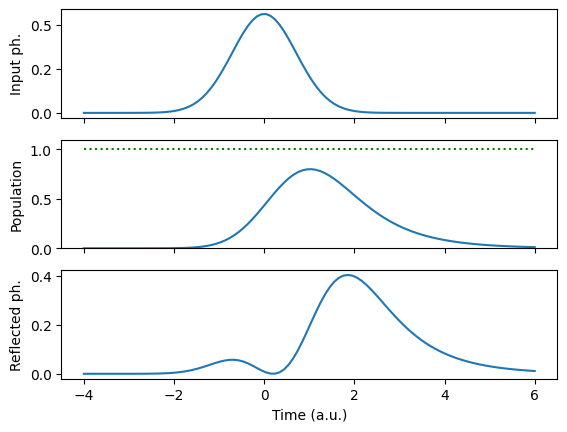

In [48]:
gm=1

initsim(nq=1)
t_,rho_ = sim(gm=gm, chi=[0], nsteps=100, t1 = -4, t2 = 6)

Pin_ = [expect(ainc*ain,rho) for rho in rho_] 
Pc_ = [expect(ac*a,rho) for rho in rho_]
Iin_ = -np.gradient(Pin_,t_)
Iout_ = [expect(OpL(t,gm).dag()*OpL(t,gm), rho_[kt]) for kt,t in enumerate(t_)]
Pout_ = cumulative_trapezoid(Iout_, t_, initial=0)
fig, ax = plt.subplots(nrows=3)

ax[0].plot(t_, Iin_, label='Pop in')
ax[0].set_ylabel('Input ph.')
ax[0].set_xticklabels([])
ax[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax[1].plot(t_, Pc_, label='Population')
ax[1].plot(t_,np.ones(len(t_)),'g:')
ax[1].set_ylabel('Population')
ax[1].set_ylim([0,1.1])
ax[1].set_xticklabels([])
ax[2].plot(t_, Iout_, label='Pop out')
ax[2].set_ylabel('Reflected ph.')
# ax.plot(t_, Iin_, label='Flux in')
# ax.plot(t_, Iout_, label='Flux out')
ax[2].set_xlabel('Time (a.u.)')
# plt.legend()
print(max(Pc_))

Text(0, 0.5, 'Max population')

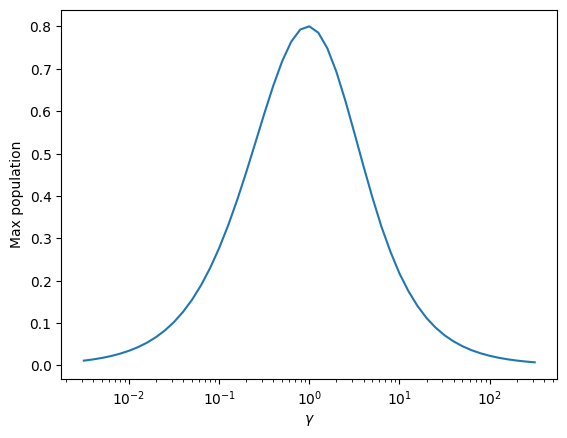

In [46]:
initsim(nq=1)
gm_ = np.logspace(-2.5,2.5,51)
Pmax_ = []
for gm in gm_:
    t_,rho_ = sim(gm=gm, chi=[0], nsteps=100, t1 = -4, t2 = 6)
    Pc_ = [expect(ac*a,rho) for rho in rho_]
    Pmax = max(Pc_)
    Pmax_.append(Pmax)

fig, ax = plt.subplots()
ax.plot(gm_, Pmax_)
ax.set_xscale('log')
ax.set_xlabel(r'$\gamma$')
ax.set_ylabel('Max population')

## Forma non gaussiana ma esponenziale inversa

In [54]:
# DEFINIZIONI

import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from numpy import pi, sqrt, linspace, exp, sin, cos, abs, angle, log, max, real
from scipy.special import erf, erfc
from scipy.integrate import cumulative_trapezoid
from math import atan2
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.ticker as ticker

nlev = 2
nqubit = 2

k = 10
chi = 1*k
dchi = .0
chi1 = (1+dchi)*chi
chi2 = (1-dchi)*chi 

def u(t):  # Forma dell'impulso (definisce la scala dei tempi)
    if t<0:
        out = exp(t/2)
    else:
        out = 0
    return float(out)

def gu(t):  # Accoppiamento modulabile source per restituire u(t)
    if t<0:
        out = sqrt(exp(t)/(1-exp(t)))
    else:
        out = 0
    return float(out)

def OpL(t, gm): # Operatore di Lindblad
    return sqrt(gm)*a + gu(t)*ain

def initsim(nq=1, nl=2): # Inizializza la simulazione preparando gli operatori necessari
    global ain, a, ainc, ac, sx, sy, sz, roty, nqubit, nlev
    nqubit = nq
    nlev = nl
    ain = tensor(destroy(nlev), identity(nlev))
    a = tensor(identity(nlev), destroy(nlev))
    ident = tensor(identity(nlev), identity(nlev))
    rot0 = Qobj([[1, -1], [1, 1]]/sqrt(2))
    sx = []
    sy = []
    sz = []
    roty = ident
    for i in range(nqubit):
        ain = tensor(ain, identity(2))
        a = tensor(a, identity(2))
        roty = tensor(roty, rot0)
        sx.append(ident)
        sy.append(ident)
        sz.append(ident)
        for j in range(nqubit):
            sx[i]=tensor(sx[i], sigmax() if i==j else identity(2))
            sy[i]=tensor(sy[i], sigmay() if i==j else identity(2))
            sz[i]=tensor(sz[i], sigmaz() if i==j else identity(2))
    ainc = ain.dag()
    ac = a.dag()

def sim(gm = 10, chi = [], t1=-3, t2=3, nsteps=100): # Simulazione
    t_ = linspace(t1, t2, nsteps)
    psi0 = tensor(basis(nlev,1), basis(nlev,0))
    for i in range(nqubit):
        psi0 = tensor(psi0, (basis(2,0)+basis(2,1))/sqrt(2))
    Hc = 1j/2*sqrt(gm)*(ainc*a-ain*ac)
    Hq = 0
    for i in range(nqubit):
        Hq = Hq -chi[i]/2*ac*a*sz[i]
    H = [Hq,[Hc, gu]]
    L = [lambda t, args: OpL(t, gm)]
    rho_ = mesolve(H, psi0, t_, L).states
    return t_, rho_

def plotrho(rho): # Plot della matrice densità con l'approccio clocklike
    fig, ax = plt.subplots()
    R = .45
    amp = abs(rho.full())
    phase = angle(rho.full())
    N = len(amp)
    bit = int(np.log2(N))
    circ = []
    lin = []
    for i in range(N):
        ax.text(i-.1, -.8, bin(i)[2:].zfill(bit), fontsize=8, color='black', ha='center', va='top', rotation = -90)
        ax.text(-.8, i-.1, bin(i)[2:].zfill(bit), fontsize=8, color='black', ha='right')
        for j in range(N):
            circle0 = plt.Circle((i, j), R, fill=False, edgecolor='blue', linewidth=.2)
            ax.add_patch(circle0)
            square = plt.Rectangle((i-.5, j-.5), 1, 1, fill=False, edgecolor='black', linewidth=.1)
            ax.add_patch(square)
            circle = plt.Circle((i, j), R*sqrt(amp[i,j]), color=plt.cm.hsv((phase[i,j]/(2*pi)+.5)%1), alpha=.5)
            circ.append(ax.add_patch(circle))
            pl, = ax.plot([i, i + R*sqrt(amp[i,j])*np.cos(phase[i,j])], [j, j + R*amp[i,j]*np.sin(phase[i,j])], color='black', linewidth=0.8)
            lin.append(pl)
    ax.set_aspect('equal')
    ax.set_xlim(-0.5, N-0.5)
    ax.set_ylim(-1., N-0.5)
    ax.axis('off')
    return fig, ax, circ, lin

def animaterho(t_,rho_): # Animazione della matrice densità con l'approccio clocklike
    fig, ax, circ, lin = plotrho(rho_[0])
    plt.close()
    N = int(sqrt(len(circ)))
    def update(frame):
        R = .45
        rho = rho_[frame].full()
        amp = sqrt(abs(rho))
        phase = angle(rho)
        for i in range(N):
            for j in range(N):
                circ[i+N*j].set_radius(R*amp[i,j])
                circ[i+N*j].set_color(plt.cm.hsv((phase[i,j]/(2*pi)+.5)%1))
                lin[i+N*j].set_data([i, i + R*amp[i,j]*np.cos(phase[i,j])], [j, j + R*amp[i,j]*np.sin(phase[i,j])])
        ax.set_title(f"t = {t_[frame]:.2f} frame={frame}")
        return circ, lin
    anim = FuncAnimation(fig, update, frames=len(t_), blit=False, repeat=False)
    return anim

def rotation(rho): # Rotazione finale della matrice densità
    rho1 = roty*rho*roty.dag()
    return rho1
    
def prob(rho): # Diagonal elements of a density matrix
    rhored = ptrace(rho, [kq+2 for kq in range(nqubit)])
    return abs(np.diag(rhored.full()))

def phaseq(rho):
    return [angle((ptrace(rho, 2+kq).full())[0,1])%(2*pi) for kq in range(nqubit)]

def plotpop(t_, rho_, gm):
    Pin_ = [expect(ainc*ain,rho) for rho in rho_] 
    Pc_ = [expect(ac*a,rho) for rho in rho_]
    Iin_ = -np.gradient(Pin_,t_)
    Iout_ = [expect(OpL(t,gm).dag()*OpL(t,gm), rho_[kt]) for kt,t in enumerate(t_)]
    Pout_ = cumulative_trapezoid(Iout_, t_, initial=0)
    fig, ax = plt.subplots()
    ax.plot(t_, Pin_, label='Pop in')
    ax.plot(t_, Pc_, label='Pop cavity')
    ax.plot(t_, Pout_, label='Pop out')
    ax.plot(t_, Iin_, label='Flux in')
    ax.plot(t_, Iout_, label='Flux out')
    ax.set_xlabel('Time')
    ax.set_ylabel('Population / Flux')
    plt.legend()
    return Iin_

def plotphase(t_, rho_):
    fig, ax = plt.subplots()
    for kq in range(nqubit):
        Pphase_ = [phaseq(rho) for rho in rho_]
        ax.plot(t_, Pphase_, label=f'Phase qubit {kq+1}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Phase (rad)')
    plt.legend()

0.9718662542461131


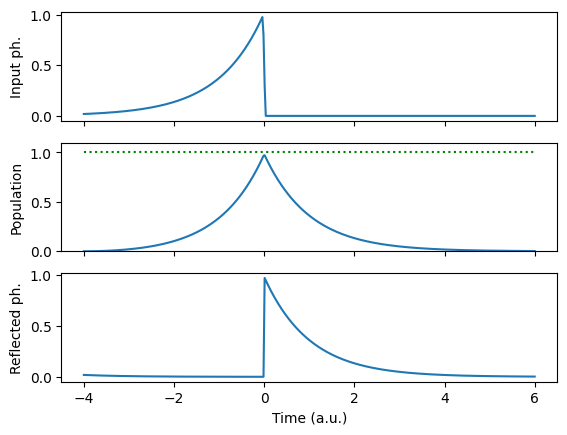

In [57]:
gm=1

initsim(nq=1)
t_,rho_ = sim(gm=gm, chi=[0], nsteps=400, t1 = -4, t2 = 6)

Pin_ = [expect(ainc*ain,rho) for rho in rho_] 
Pc_ = [expect(ac*a,rho) for rho in rho_]
Iin_ = -np.gradient(Pin_,t_)
Iout_ = [expect(OpL(t,gm).dag()*OpL(t,gm), rho_[kt]) for kt,t in enumerate(t_)]
Pout_ = cumulative_trapezoid(Iout_, t_, initial=0)
fig, ax = plt.subplots(nrows=3)

ax[0].plot(t_, Iin_, label='Pop in')
ax[0].set_ylabel('Input ph.')
ax[0].set_xticklabels([])
ax[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax[1].plot(t_, Pc_, label='Population')
ax[1].plot(t_,np.ones(len(t_)),'g:')
ax[1].set_ylabel('Population')
ax[1].set_ylim([0,1.1])
ax[1].set_xticklabels([])
ax[2].plot(t_, Iout_, label='Pop out')
ax[2].set_ylabel('Reflected ph.')
# ax.plot(t_, Iin_, label='Flux in')
# ax.plot(t_, Iout_, label='Flux out')
ax[2].set_xlabel('Time (a.u.)')
# plt.legend()
print(max(Pc_))

0.9863216726856445


Text(0, 0.5, 'Max population')

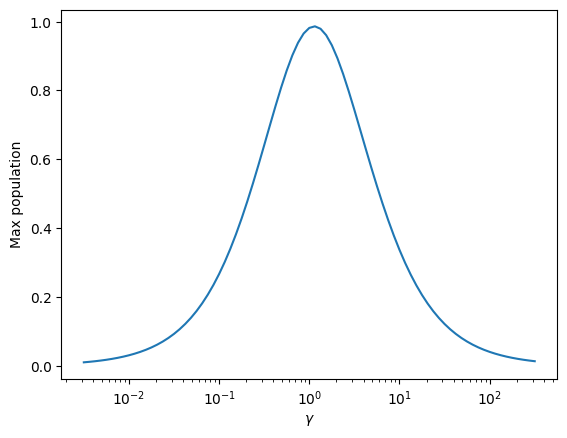

In [64]:
initsim(nq=1)
gm_ = np.logspace(-2.5,2.5,81)
Pmax_ = []
for gm in gm_:
    t_,rho_ = sim(gm=gm, chi=[0], nsteps=401, t1 = -4, t2 = 4)
    Pc_ = [expect(ac*a,rho) for rho in rho_]
    Pmax = max(Pc_)
    Pmax_.append(Pmax)

print(max(Pmax_))
fig, ax = plt.subplots()
ax.plot(gm_, Pmax_)
ax.set_xscale('log')
ax.set_xlabel(r'$\gamma$')
ax.set_ylabel('Max population')

In [12]:
# SWEEP CHI/GAMMA, 3 QUBIT PARALLELIZZATO
import concurrent.futures

# Funzione da parallelizzare
def run_sim(chi_val):
    initsim(nq=3)
    gm = 10
    t_, rho_ = sim(gm=gm, chi=[chi_val, chi_val, chi_val])
    rho1 = rotation(rho_[-1])
    return prob(rho1), phaseq(rho_[-1])


gm = 10
chi_ = np.logspace(-2,2,41)*gm
P_ = []
ph_ = []

'''
for chi in chi_:
    t_,rho_ = sim(gm=gm, chi=[chi, chi, chi], nsteps=50)
    rho1 = rotation(rho_[-1])
    P_.append(prob(rho1))
    ph_.append(phaseq(rho_[-1]))
'''

with concurrent.futures.ProcessPoolExecutor() as executor:
    results = list(executor.map(run_sim, chi_))
P_ = [r[0] for r in results]
ph_ = [r[1] for r in results]

fig, ax = plt.subplots()
lines = plt.plot(chi_/gm, P_)
ax.legend(title='Final state', handles=lines, labels=[bin(k)[2:].zfill(nqubit) for k in range(2**(nqubit))])
ax.set_xscale('log')
ax.set_xlabel(r'$\chi/\gamma$')
ax.set_ylabel('Final probability')
plt.figure(2)
lines = plt.plot(chi_/gm, ph_)
plt.legend(title='Qubit', handles=lines, labels=[k for k in range(nqubit)])
plt.xscale('log')
plt.xlabel(r'$\chi/\gamma$')
plt.ylabel('Phase (rad)')

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.